# Test 1 — Річний огляд платежів (2022)

**Мета:** описова статистика платіжного домену, тренди, аномалії, гіпотези про причини, рекомендації.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

MONTHS = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
WEEKDAYS = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

# 1. Ознайомлення з датасетом

In [2]:
df = pd.read_csv("../data/test_1_payment_data/test_1_payment_data.csv")
df = df.drop(columns=['#'], errors='ignore')
display(df.head(3))
df.info(memory_usage="deep")

,order_id,event_time,user_id,price,payment_number,transaction_status,card_brand,card_type,bank_name,error_type,currency,card_country
0,c500aa10-30f8-4927-96c5-4e97b6afac83,2022-07-08 18:32:39.000000,c1ed5188-caac-4d56-bad8-bc8ee0b09960,21.00,reccurent,fail,VISA,PREPAID,ADVANCED BANK OF ASIA LIMITED,3.08,USD,KHM
1,624d6f30-c1bc-4778-a23e-6a227bac73ac,2022-06-09 22:18:36.000000,c9ff65b8-75e6-467f-8715-21edb5fd06af,36.00,reccurent,fail,VISA,PREPAID,UNITED BANK FOR AFRICA GHANA LIMITED,3.02,USD,GHA
2,4d75ca57-8883-49a9-b150-1ab7a47d12f8,2022-06-09 11:18:32.000000,1005d4fb-1b7d-4715-835f-4d2a9bfe7cbb,36.00,initial,success,VISA,CREDIT,ICICI BANK LTD,NaN,USD,IND


<class 'pandas.DataFrame'>
RangeIndex: 566413 entries, 0 to 566412
Data columns (total 12 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   order_id            566413 non-null  str    
 1   event_time          566413 non-null  str    
 2   user_id             566413 non-null  str    
 3   price               566413 non-null  float64
 4   payment_number      566413 non-null  str    
 5   transaction_status  566413 non-null  str    
 6   card_brand          566413 non-null  str    
 7   card_type           565643 non-null  str    
 8   bank_name           564404 non-null  str    
 9   error_type          313048 non-null  float64
 10  currency            566413 non-null  str    
 11  card_country        565886 non-null  str    
dtypes: float64(2), str(10)
memory usage: 356.2 MB


# 2. Підготовка: дата й допоміжні поля

Значення `payment_number` у даних написано як `reccurent` (з помилкою) — залишаємо як є, щоб не ламати фільтри.

In [3]:
df['event_time'] = pd.to_datetime(df['event_time'])
print("Роки в даних:", df['event_time'].dt.year.value_counts().to_dict())
print("Статуси:", df['transaction_status'].unique().tolist())
print("Типи платежів:", df['payment_number'].unique().tolist())

df['month'] = df['event_time'].dt.month
df['day'] = df['event_time'].dt.day
df['hour'] = df['event_time'].dt.hour
df['dayofweek'] = df['event_time'].dt.dayofweek
df['date'] = df['event_time'].dt.normalize()

df['is_success'] = (df['transaction_status'] == 'success').astype(int)
df['revenue'] = df['price'] * df['is_success']      # дохід = сума успішних платежів у ВАЛЮТІ платежу

Роки в даних: {2022: 566413}
Статуси: ['fail', 'success']
Типи платежів: ['reccurent', 'initial']


# 3. Описова статистика

In [4]:
print("Загальна кількість транзакцій:", f"{len(df):,}")
print("Унікальних user:", f"{df['user_id'].nunique():,}")
print("Унікальних order_id:", f"{df['order_id'].nunique():,}", "(дорівнює кількості рядків → 1 рядок = 1 спроба оплати)")
print("Дублікатів рядків:", df.duplicated().sum())
print(f"Загальний success rate: {df['is_success'].mean()*100:.2f}%")

miss = df.isnull().sum()
miss = miss[miss > 0].to_frame('missing')
miss['%'] = (miss['missing'] / len(df) * 100).round(2)
display(miss)

# error_type: чи збігається «порожнє» з «успішне»?
fail_no_code = ((df['transaction_status'] == 'fail') & df['error_type'].isna()).sum()
succ_with_code = ((df['transaction_status'] == 'success') & df['error_type'].notna()).sum()
print(f"fail БЕЗ error_type: {fail_no_code:,};  success З error_type: {succ_with_code:,}")

Загальна кількість транзакцій: 566,413
Унікальних user: 115,245
Унікальних order_id: 565,315 (дорівнює кількості рядків → 1 рядок = 1 спроба оплати)
Дублікатів рядків: 1098
Загальний success rate: 44.57%


,missing,%
card_type,770,0.14
bank_name,2009,0.35
error_type,253365,44.73
card_country,527,0.09


fail БЕЗ error_type: 907;  success З error_type: 1


In [5]:
for col in ['transaction_status', 'payment_number', 'card_brand', 'card_type', 'currency']:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False).head(10))
    print()

--- transaction_status ---
transaction_status
fail       313954
success    252459
Name: count, dtype: int64

--- payment_number ---
payment_number
reccurent    424081
initial      142332
Name: count, dtype: int64

--- card_brand ---
card_brand
VISA              362953
MASTERCARD        191957
AMEX                6884
DISCOVER            1912
RUPAY               1575
MAESTRO              537
DINERS CLUB          204
VERVE                203
CHINA UNIONPAY        74
LOCAL BRAND           57
Name: count, dtype: int64

--- card_type ---
card_type
DEBIT             369968
CREDIT            140583
PREPAID            53396
DEFERRED DEBIT      1164
NaN                  770
CREDIT/DEBIT         518
CHARGE CARD           14
Name: count, dtype: int64

--- currency ---
currency
USD    518177
EUR     48236
Name: count, dtype: int64



## 3.1 Валюти: USD і EUR не можна складати

У даних дві валюти. Курсу в завданні немає, тому дохід рахуємо **окремо по кожній валюті**.

In [6]:
cur = df.groupby('currency').agg(
    tx=('order_id', 'count'),
    users=('user_id', 'nunique'),
    success_rate=('is_success', lambda s: s.mean() * 100),
    avg_price=('price', 'mean'),
    revenue=('revenue', 'sum'),
)
cur['share_of_tx_%'] = cur['tx'] / cur['tx'].sum() * 100
display(cur)

cur_month = df.pivot_table(index='month', columns='currency', values='is_success', aggfunc='mean') * 100
display(cur_month.round(1))

,tx,users,success_rate,avg_price,revenue,share_of_tx_%
currency,,,,,,
EUR,48236,11812,45.70,26.23,"487,368.00",8.52
USD,518177,104483,44.47,24.49,"5,100,298.00",91.48


currency,EUR,USD
month,,
1,NaN,56.30
2,NaN,57.70
3,NaN,55.30
4,46.80,50.90
5,42.40,47.50
6,46.30,45.50
7,45.90,40.90
8,45.50,45.00
9,36.60,40.20


## 3.2 Success rate за типом картки, брендом і країною

In [7]:
def sr_table(col, min_tx=1000, top=12):
    t = df.groupby(col).agg(tx=('order_id', 'count'), success_rate=('is_success', lambda s: s.mean() * 100))
    t['share_%'] = t['tx'] / len(df) * 100
    return t[t['tx'] >= min_tx].sort_values('tx', ascending=False).head(top)

for col in ['card_type', 'card_brand', 'card_country']:
    print(f"--- success rate за {col} (групи ≥1000 транзакцій) ---")
    display(sr_table(col))

--- success rate за card_type (групи ≥1000 транзакцій) ---


,tx,success_rate,share_%
card_type,,,
DEBIT,369968,45.60,65.32
CREDIT,140583,51.74,24.82
PREPAID,53396,18.62,9.43
DEFERRED DEBIT,1164,75.60,0.21


--- success rate за card_brand (групи ≥1000 транзакцій) ---


,tx,success_rate,share_%
card_brand,,,
VISA,362953,44.69,64.08
MASTERCARD,191957,45.25,33.89
AMEX,6884,39.58,1.22
DISCOVER,1912,32.01,0.34
RUPAY,1575,0.00,0.28


--- success rate за card_country (групи ≥1000 транзакцій) ---


,tx,success_rate,share_%
card_country,,,
USA,240649,42.57,42.49
CAN,36872,50.92,6.51
AUS,34558,53.05,6.10
IND,28333,30.91,5.00
MEX,17629,29.76,3.11
GBR,15299,53.60,2.70
NZL,10407,52.38,1.84
ROU,8329,49.07,1.47
SGP,7671,62.59,1.35


## 3.3 Транзакції на користувача

count   115,245.00
mean          4.91
std           6.43
min           1.00
25%           1.00
50%           2.00
75%           6.00
max         109.00
dtype: float64


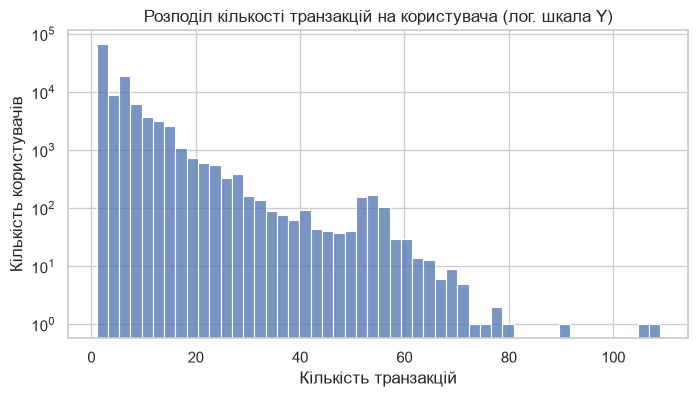

In [8]:
tx_per_user = df.groupby('user_id').size()
print(tx_per_user.describe())

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(tx_per_user, bins=50, ax=ax)
ax.set_yscale('log')
ax.set_title('Розподіл кількості транзакцій на користувача (лог. шкала Y)')
ax.set_xlabel('Кількість транзакцій'); ax.set_ylabel('Кількість користувачів')
plt.show()

## 3.4 Ціна (окремо по валютах)

count  mean   std  min   25%   50%   75%  \
currency transaction_status                                                 
EUR      fail                26,191.00 29.69 14.73 4.00 14.00 36.00 43.00   
         success             22,045.00 22.11 16.24 4.00  6.00 14.00 36.00   
USD      fail               287,763.00 26.38 16.83 4.00  9.00 33.00 36.00   
         success            230,414.00 22.14 13.51 4.00  9.00 21.00 36.00   

                               max  
currency transaction_status         
EUR      fail                90.00  
         success             90.00  
USD      fail               107.00  
         success             90.00

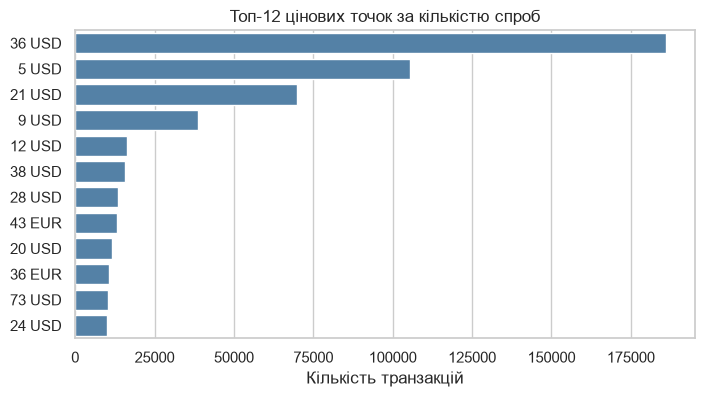

Унікальних цін: 42 → ціни фіксовані (тарифні плани), а не довільні суми


In [9]:
display(df.groupby(['currency', 'transaction_status'])['price'].describe())

top_prices = (df.groupby(['currency', 'price']).size().rename('tx').reset_index()
                .sort_values('tx', ascending=False).head(12))
top_prices['label'] = top_prices['price'].astype(int).astype(str) + ' ' + top_prices['currency']
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=top_prices, y='label', x='tx', color='steelblue', ax=ax)
ax.set_title('Топ-12 цінових точок за кількістю спроб'); ax.set_xlabel('Кількість транзакцій'); ax.set_ylabel('')
plt.show()
print("Унікальних цін:", df['price'].nunique(), "→ ціни фіксовані (тарифні плани), а не довільні суми")

# 4. Сезонність: місяць / день місяця / день тижня / година

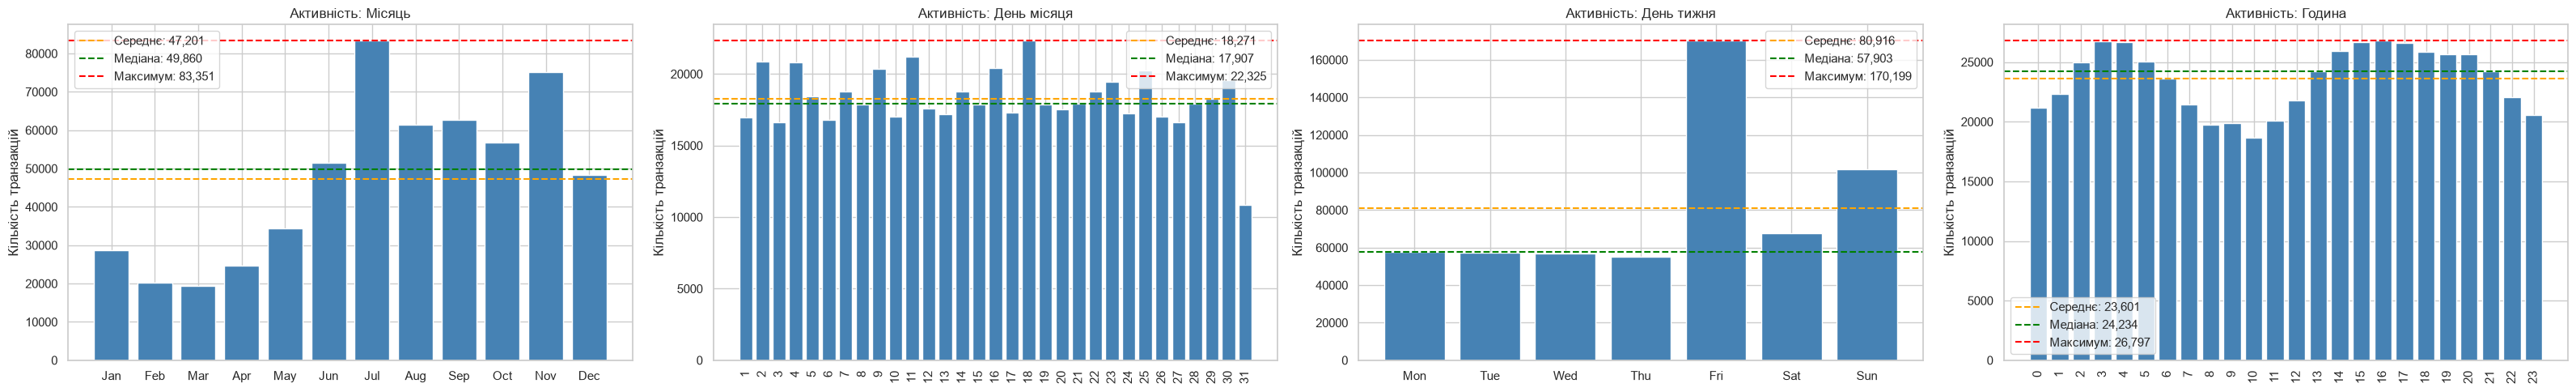

Пік за місяцем: Jul (83,351); мінімум: Mar (19,452); пік/мінімум = 4.3x
Примітка: дні 29–31 мають менше спостережень просто тому, що не в кожному місяці вони існують.


In [10]:
def add_ref_lines(ax, counts):
    ax.axhline(counts.mean(), color='orange', ls='--', lw=1.5, label=f'Середнє: {counts.mean():,.0f}')
    ax.axhline(counts.median(), color='green', ls='--', lw=1.5, label=f'Медіана: {counts.median():,.0f}')   # було: max_val
    ax.axhline(counts.max(), color='red', ls='--', lw=1.5, label=f'Максимум: {counts.max():,.0f}')
    ax.legend()

fig, axes = plt.subplots(1, 4, figsize=(32, 5))
specs = [('month', range(1, 13), MONTHS, 'Місяць'),
         ('day', range(1, 32), list(range(1, 32)), 'День місяця'),
         ('dayofweek', range(7), WEEKDAYS, 'День тижня'),
         ('hour', range(24), list(range(24)), 'Година')]
for ax, (col, order, labels, title) in zip(axes, specs):
    counts = df[col].value_counts().reindex(list(order), fill_value=0).sort_index()
    ax.bar(range(len(counts)), counts.values, color='steelblue')
    ax.set_xticks(range(len(counts))); ax.set_xticklabels(labels, rotation=90 if len(counts) > 12 else 0)
    ax.set_title(f'Активність: {title}'); ax.set_ylabel('Кількість транзакцій')
    add_ref_lines(ax, counts)
plt.tight_layout(); plt.show()

m = df['month'].value_counts().sort_index()
print(f"Пік за місяцем: {MONTHS[m.idxmax()-1]} ({m.max():,}); мінімум: {MONTHS[m.idxmin()-1]} ({m.min():,}); пік/мінімум = {m.max()/m.min():.1f}x")
print("Примітка: дні 29–31 мають менше спостережень просто тому, що не в кожному місяці вони існують.")

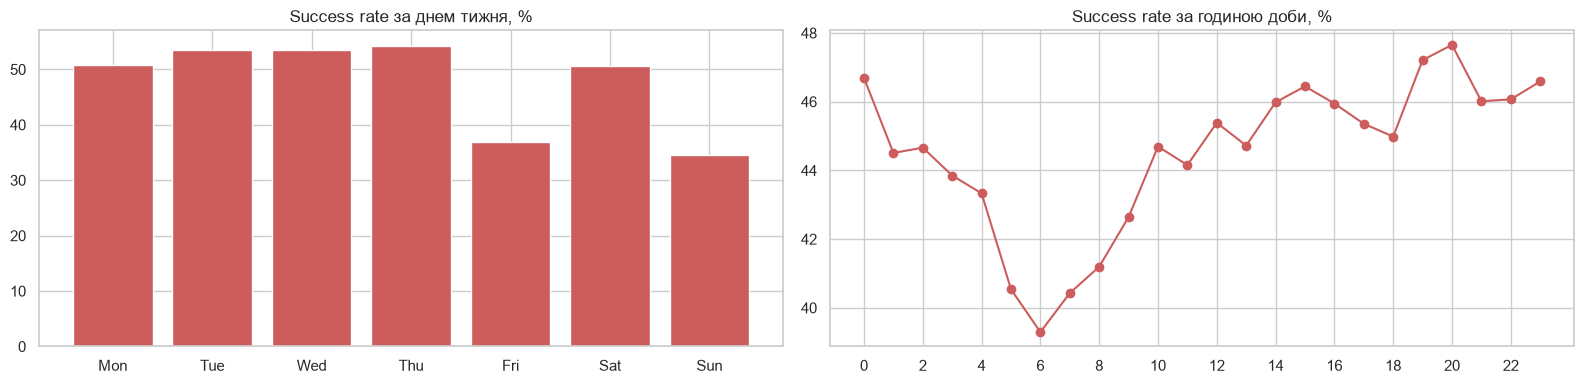

Success rate за днем тижня: від 34.5% до 54.3%;  за годиною: від 39.3% до 47.7%


In [11]:
# Success rate за днем тижня і годиною: чи є «погані» вікна?
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
sr_dow = df.groupby('dayofweek')['is_success'].mean() * 100
axes[0].bar(range(7), sr_dow.values, color='indianred'); axes[0].set_xticks(range(7)); axes[0].set_xticklabels(WEEKDAYS)
axes[0].set_title('Success rate за днем тижня, %')
sr_h = df.groupby('hour')['is_success'].mean() * 100
axes[1].plot(sr_h.index, sr_h.values, marker='o', color='indianred'); axes[1].set_xticks(range(0, 24, 2))
axes[1].set_title('Success rate за годиною доби, %')
plt.tight_layout(); plt.show()
print(f"Success rate за днем тижня: від {sr_dow.min():.1f}% до {sr_dow.max():.1f}%;  за годиною: від {sr_h.min():.1f}% до {sr_h.max():.1f}%")

# 5. Коди помилок

Розшифровка за документацією Solidgate (docs.solidgate.com → Error codes). Виправлено: `0.01` — *General decline*, `4.09` — *Antifraud service*, додано `3.09`.
Решта описів залишена з першої версії — їх варто ще раз звірити з документацією перед здачею.

In [12]:
error_code_map = {
    0.01: "Загальна відмова (General decline)", 0.02: "Час замовлення вичерпано", 0.03: "Заборонена операція (юридичні обмеження)",
    2.01: "Помилка валідації даних", 2.02: "Некоректна сума", 2.06: "Невірний CVV", 2.08: "Невірний номер картки",
    2.09: "Невірний термін дії картки", 2.10: "Помилка 3DS на боці мерчанта", 2.11: "Помилка 3DS на боці банку",
    2.14: "Помилка підписки", 2.15: "Потрібна 3D-автентифікація (SCA)", 2.16: "Підписка заблокована (в процесі створення)",
    3.01: "Картка заблокована банком", 3.02: "Недостатньо коштів (Insufficient funds)", 3.03: "Перевищено ліміт суми",
    3.04: "Відхилено банком-емітентом", 3.05: "Зателефонуйте в банк", 3.07: "Бренд картки не підтримується",
    3.08: "Do not honor (загальна відмова емітента)", 3.09: "Потрібна 3D Secure автентифікація",
    3.10: "Підозра на шахрайство (Suspected fraud)",
    4.01: "Картка в чорному списку", 4.02: "Викрадена картка", 4.03: "Обмежена картка (заблокована/під санкціями)",
    4.04: "Втрачена картка", 4.05: "Антифрод еквайра (PSP antifraud)", 4.06: "Заблоковано за країною/IP",
    4.09: "Сервіс антифроду (Antifraud service)",
    5.01: "Помилка 3DS-верифікації", 5.02: "Невірний токен картки", 5.03: "Помилка застосунку (технічна)",
    5.04: "Мерчант некоректно налаштований", 5.06: "Дублікат замовлення", 5.07: "Перевищено ліміт API-запитів",
    5.08: "Помилка транзакції (технічна)", 5.11: "Невірний роутинг", 6.01: "Невідомий код відмови", 6.02: "Помилка з'єднання",
    7.01: "Токен картки не знайдено", 7.03: "Smart cascade decline (помилка токена)", 7.07: "Помилка SCA-рушія",
}

def describe_error(code):
    if pd.isna(code):
        return 'Код відсутній'
    return error_code_map.get(code, f'Невідомий код {code}')

df['error_desc'] = df['error_type'].map(describe_error)
fails = df[df['transaction_status'] == 'fail']

error_summary = fails['error_desc'].value_counts().rename('count').to_frame()
error_summary['share_%'] = (error_summary['count'] / error_summary['count'].sum() * 100).round(2)
display(error_summary.head(15))

,count,share_%
error_desc,,
Недостатньо коштів (Insufficient funds),134691,42.90
Підозра на шахрайство (Suspected fraud),44002,14.02
Do not honor (загальна відмова емітента),26442,8.42
Відхилено банком-емітентом,15163,4.83
Обмежена картка (заблокована/під санкціями),12798,4.08
Антифрод еквайра (PSP antifraud),12772,4.07
Картка заблокована банком,12658,4.03
Невірний номер картки,8723,2.78
Загальна відмова (General decline),8468,2.70


**Висновок:** майже половина відмов (~43%) — `Недостатньо коштів` (3.02), далі `Підозра на шахрайство` (3.10, ~14%) і `Do not honor` (3.08, ~8%).
Згідно з документацією Solidgate, 3.02 — *soft decline* (можна повторювати), а 3.10, 4.05, 4.09, 4.02 — *hard decline* (повторювати не можна). Це важливо для рекомендацій щодо retry нижче.

# 6. Тренди: обсяг, success rate, дохід

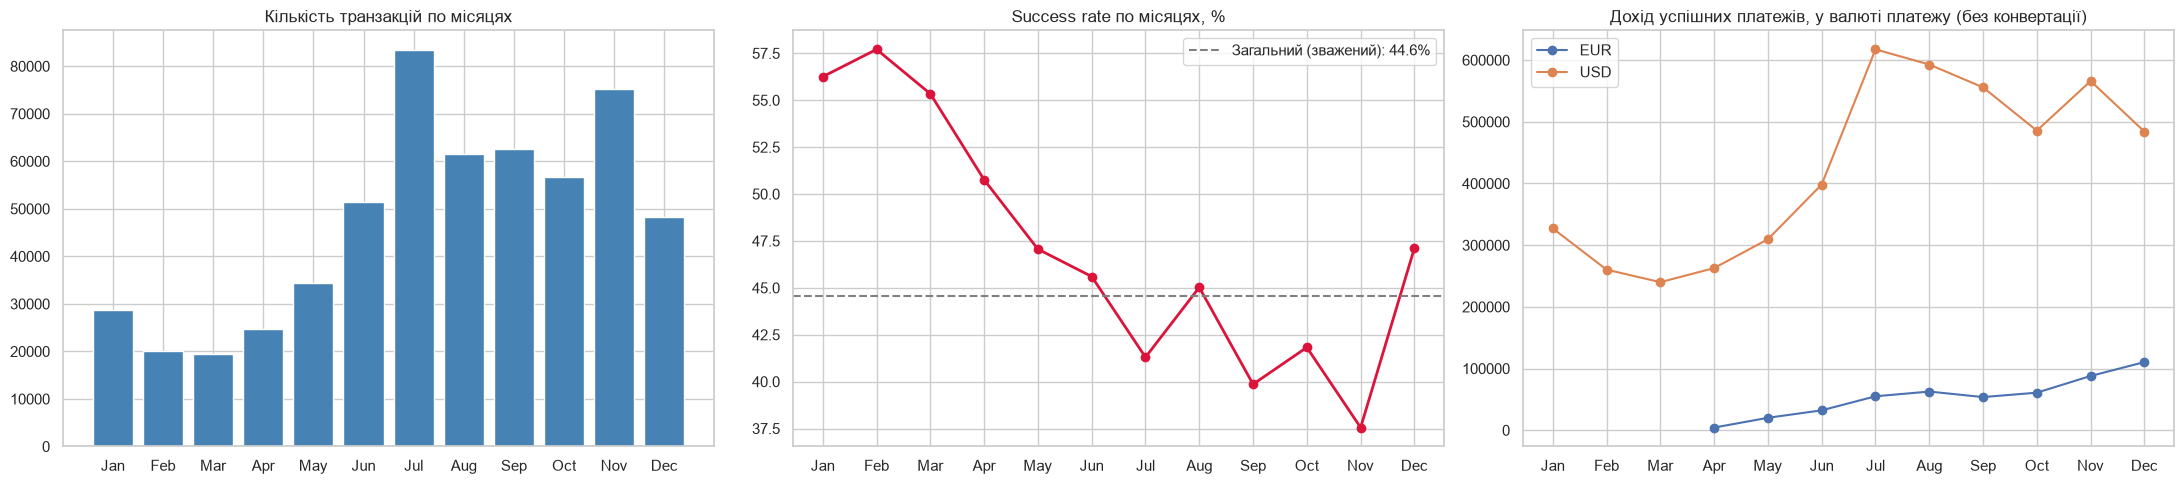

,tx_count,success_count,users,success_rate,revenue_EUR,revenue_USD
month,,,,,,
1,28665,16125,9576,56.30,NaN,"327,184.00"
2,20151,11629,7744,57.70,NaN,"260,327.00"
3,19452,10765,7525,55.30,NaN,"240,012.00"
4,24762,12569,9136,50.80,"4,316.00","262,844.00"
5,34345,16163,11732,47.10,"20,139.00","309,624.00"
6,51452,23463,19383,45.60,"32,231.00","398,349.00"
7,83351,34425,27754,41.30,"55,024.00","617,407.00"
8,61434,27660,20445,45.00,"62,649.00","592,880.00"
9,62598,24952,20318,39.90,"53,743.00","555,786.00"


Обсяг: 28,665 (Jan) → пік 83,351 (Jul), ×2.9
Success rate: 56.3% (Jan); мінімум 37.6% (Nov); Dec 47.1%


In [13]:
monthly = df.groupby('month').agg(
    tx_count=('order_id', 'count'),
    success_count=('is_success', 'sum'),
    users=('user_id', 'nunique'),
)
monthly['success_rate'] = monthly['success_count'] / monthly['tx_count'] * 100
rev = df.pivot_table(index='month', columns='currency', values='revenue', aggfunc='sum').add_prefix('revenue_')
monthly = monthly.join(rev)
overall_sr = df['is_success'].mean() * 100

fig, axes = plt.subplots(1, 3, figsize=(22, 5))
axes[0].bar(monthly.index, monthly['tx_count'], color='steelblue')
axes[0].set_title('Кількість транзакцій по місяцях')

axes[1].plot(monthly.index, monthly['success_rate'], marker='o', color='crimson', lw=2)
axes[1].axhline(overall_sr, color='gray', ls='--', label=f'Загальний (зважений): {overall_sr:.1f}%')
axes[1].set_title('Success rate по місяцях, %'); axes[1].legend()

for c_ in [c for c in monthly.columns if c.startswith('revenue_')]:
    axes[2].plot(monthly.index, monthly[c_], marker='o', label=c_.replace('revenue_', ''))
axes[2].set_title('Дохід успішних платежів, у валюті платежу (без конвертації)'); axes[2].legend()
for ax in axes:
    ax.set_xticks(range(1, 13)); ax.set_xticklabels(MONTHS)
plt.tight_layout(); plt.show()
display(monthly.round(1))

first, peak = monthly['tx_count'].iloc[0], monthly['tx_count'].max()
print(f"Обсяг: {first:,} (Jan) → пік {peak:,} ({MONTHS[monthly['tx_count'].idxmax()-1]}), ×{peak/first:.1f}")
print(f"Success rate: {monthly['success_rate'].iloc[0]:.1f}% (Jan); мінімум {monthly['success_rate'].min():.1f}% ({MONTHS[monthly['success_rate'].idxmin()-1]}); Dec {monthly['success_rate'].iloc[-1]:.1f}%")

**Що видно (за цифрами з таблиці):** обсяг зростає приблизно ×2.9 (з 28.7K у січні до 83.4K у липні). Success rate знижується з 56.3% у січні до мінімуму 37.6% у листопаді,
**але не монотонно**: серпень 45.0%, жовтень 41.8% і особливо **грудень 47.1%** — відновлення. Будь-яка пояснювальна версія має пояснювати і падіння, і грудневе відновлення.

## 6.1 Чи впливають повторні спроби (retry)?

Кожен рядок — окрема спроба. Якщо користувач кілька разів за день пробує оплатити, це змішує «якість платежів» і «поведінку користувачів». Перевіряємо success rate лише по **першій спробі користувача за день**.

Частка спроб, що є 2-ю і далі в межах доби: 13.1%


,tx,success_rate_%
a,,
1,492181,45.64
2,55814,42.68
3,18418,21.72


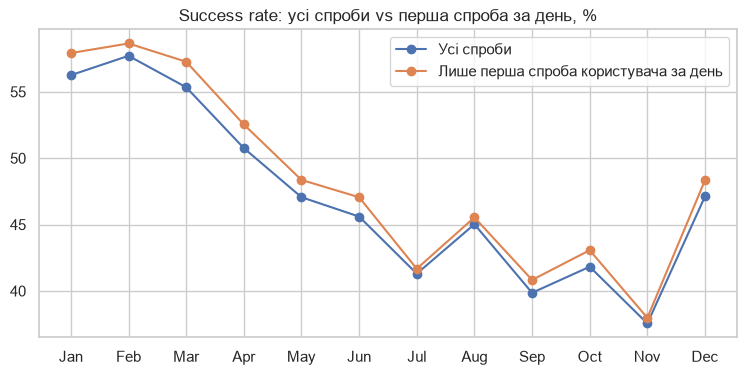

In [14]:
df = df.sort_values('event_time').reset_index(drop=True)
df['attempt_in_day'] = df.groupby(['user_id', 'date']).cumcount() + 1

print(f"Частка спроб, що є 2-ю і далі в межах доби: {(df['attempt_in_day'] > 1).mean()*100:.1f}%")
sr_attempt = df.assign(a=df['attempt_in_day'].clip(upper=3)).groupby('a')['is_success'].agg(['count', 'mean'])
sr_attempt['mean'] *= 100
display(sr_attempt.rename(columns={'count': 'tx', 'mean': 'success_rate_%'}))

sr_first = df[df['attempt_in_day'] == 1].groupby('month')['is_success'].mean() * 100
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(monthly.index, monthly['success_rate'], marker='o', label='Усі спроби')
ax.plot(sr_first.index, sr_first.values, marker='o', label='Лише перша спроба користувача за день')
ax.set_xticks(range(1, 13)); ax.set_xticklabels(MONTHS); ax.set_title('Success rate: усі спроби vs перша спроба за день, %'); ax.legend()
plt.show()

# 7. Initial vs Recurrent

`initial` — конверсія нових платників, `recurrent` — повторні списання з підписки. Це різні проблеми з різними причинами.

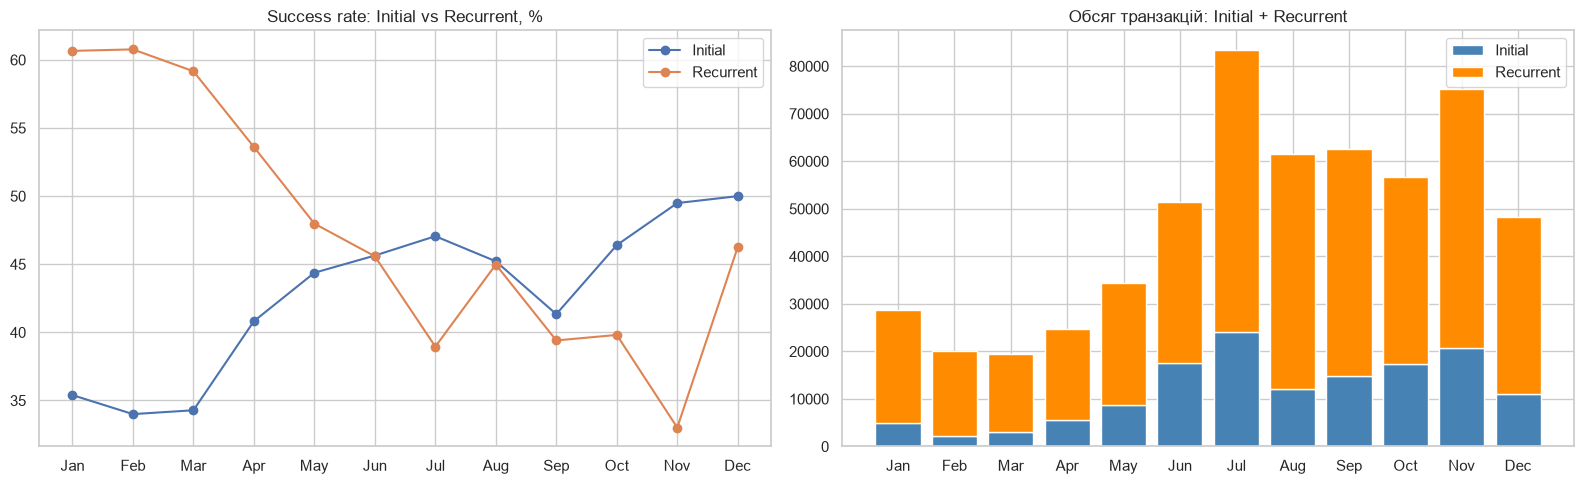

,initial_SR_%,reccurent_SR_%,recurrent_share_%
month,,,
1,35.40,60.70,82.60
2,34.00,60.80,88.60
3,34.30,59.20,84.60
4,40.80,53.60,77.70
5,44.40,48.00,74.50
6,45.60,45.60,65.80
7,47.10,39.00,71.00
8,45.20,45.00,80.30
9,41.30,39.40,76.40


In [15]:
sr_pivot = df.groupby(['month', 'payment_number'])['is_success'].mean().unstack() * 100
vol_pivot = df.groupby(['month', 'payment_number']).size().unstack()
rec_share = vol_pivot['reccurent'] / vol_pivot.sum(axis=1) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(sr_pivot.index, sr_pivot['initial'], marker='o', label='Initial')
axes[0].plot(sr_pivot.index, sr_pivot['reccurent'], marker='o', label='Recurrent')
axes[0].set_title('Success rate: Initial vs Recurrent, %'); axes[0].legend()
axes[1].bar(vol_pivot.index, vol_pivot['initial'], label='Initial', color='steelblue')
axes[1].bar(vol_pivot.index, vol_pivot['reccurent'], bottom=vol_pivot['initial'], label='Recurrent', color='darkorange')
axes[1].set_title('Обсяг транзакцій: Initial + Recurrent'); axes[1].legend()
for ax in axes:
    ax.set_xticks(range(1, 13)); ax.set_xticklabels(MONTHS)
plt.tight_layout(); plt.show()
display(pd.concat([sr_pivot.round(1).add_suffix('_SR_%'), rec_share.round(1).rename('recurrent_share_%')], axis=1))

**Що видно:** initial SR зростає з 35.4% (січень) до 50.0% (грудень); recurrent SR падає з 60.7% (січень) до 33.0% (листопад) і **відновлюється до 46.3% у грудні**.
Recurrent становить ~75% усіх транзакцій, тому саме він визначає загальну динаміку. Причини зростання initial у даних не видно — це лише гіпотези (зміна checkout, якості трафіку), потребують підтвердження від команд.

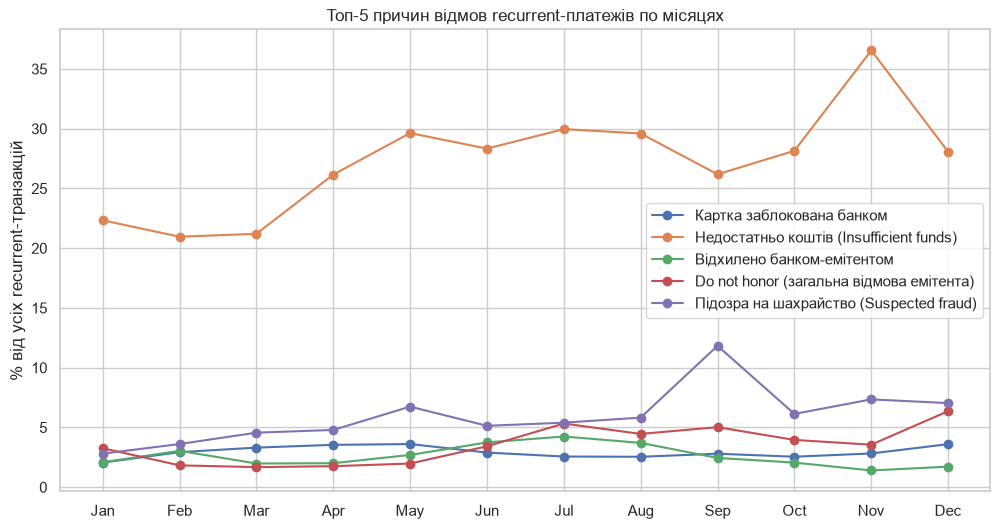

,Картка заблокована банком,Недостатньо коштів (Insufficient funds),Відхилено банком-емітентом,Do not honor (загальна відмова емітента),Підозра на шахрайство (Suspected fraud)
month,,,,,
1,2.05,22.33,2.08,3.26,2.81
2,2.93,20.96,3.04,1.83,3.61
3,3.31,21.20,1.98,1.68,4.56
4,3.54,26.16,2.00,1.76,4.79
5,3.61,29.63,2.70,1.98,6.74
6,2.90,28.33,3.74,3.42,5.14
7,2.56,29.96,4.24,5.33,5.40
8,2.54,29.60,3.70,4.46,5.82
9,2.80,26.18,2.45,5.02,11.83


In [16]:
fails_rec = fails[fails['payment_number'] == 'reccurent']
top_codes = fails_rec['error_type'].value_counts().head(5).index.tolist()
rec_total = df[df['payment_number'] == 'reccurent'].groupby('month').size()

err_trend = (fails_rec[fails_rec['error_type'].isin(top_codes)]
             .groupby(['month', 'error_type']).size().unstack(fill_value=0)
             .reindex(range(1, 13), fill_value=0))
err_trend_pct = err_trend.div(rec_total, axis=0) * 100
err_trend_pct.columns = [describe_error(c) for c in err_trend_pct.columns]

fig, ax = plt.subplots(figsize=(12, 6))
for col in err_trend_pct.columns:
    ax.plot(err_trend_pct.index, err_trend_pct[col], marker='o', label=col)
ax.set_xticks(range(1, 13)); ax.set_xticklabels(MONTHS)
ax.set_ylabel('% від усіх recurrent-транзакцій'); ax.set_title('Топ-5 причин відмов recurrent-платежів по місяцях')
ax.legend(); plt.show()
display(err_trend_pct.round(2))

**Що видно:** `Недостатньо коштів` (3.02) у recurrent: 22.3% (січень) → 26–30% з квітня по грудень, з піком 36.6% у листопаді (не «29–36% у другому півріччі», як було в першій версії: вересень 26.2%, жовтень 28.2%, грудень 28.1%).
`Підозра на шахрайство` (3.10) має різкий пік у вересні (11.8%).
Гіпотеза «старіння когорт» (що довше живе підписник, то частіше немає коштів) **у цьому ноутбуці не перевірена** — для неї потрібен cohort/tenure-аналіз по `user_id` (див. розділ 10).

# 8. Аномалії: SUTTON BANK та код 4.05 — розглядаємо разом

Обидві аномалії з'являються у вересні–листопаді й зникають у грудні, тому спершу перевіряємо, чи це одна історія.

In [17]:
bank_stats = df.groupby('bank_name').agg(
    tx_count=('order_id', 'count'),
    success_rate=('is_success', lambda x: x.mean() * 100),
    prepaid_share=('card_type', lambda x: (x == 'PREPAID').mean() * 100),
).sort_values('tx_count', ascending=False)
bank_stats['share_of_total_%'] = bank_stats['tx_count'] / len(df) * 100
print("Топ-15 банків за обсягом:")
display(bank_stats.head(15).round(1))

big_low = bank_stats[(bank_stats['tx_count'] >= 5000) & (bank_stats['success_rate'] < 30)]
print("Великі банки (≥5000 tx) з success rate <30%:")
display(big_low.round(1))

Топ-15 банків за обсягом:


,tx_count,success_rate,prepaid_share,share_of_total_%
bank_name,,,,
SUTTON BANK,29356,15.20,96.20,5.20
"BANK OF AMERICA, NATIONAL ASSOCIATION",15210,63.10,9.70,2.70
JPMORGAN CHASE BANK N.A. - DEBIT,15171,68.40,0.00,2.70
THE BANCORP BANK,14655,27.50,16.40,2.60
"WELLS FARGO BANK, NATIONAL ASSOCIATION",12900,58.90,0.00,2.30
COMMONWEALTH BANK OF AUSTRALIA,12251,52.60,1.00,2.20
"STRIDE BANK, NATIONAL ASSOCIATION",9503,24.50,11.40,1.70
"CAPITAL ONE BANK (USA), NATIONAL ASSOCIATION",6944,51.30,0.00,1.20
THE TORONTO-DOMINION BANK,6792,41.80,0.00,1.20


Великі банки (≥5000 tx) з success rate <30%:


,tx_count,success_rate,prepaid_share,share_of_total_%
bank_name,,,,
SUTTON BANK,29356,15.20,96.20,5.20
THE BANCORP BANK,14655,27.50,16.40,2.60
"STRIDE BANK, NATIONAL ASSOCIATION",9503,24.50,11.40,1.70
METABANK,5356,20.40,66.30,0.90
REVOLUT LIMITED,5347,29.00,0.00,0.90


З виводу першої версії: окрім SUTTON BANK (15.2%), низький success rate мають **THE BANCORP BANK (27.5%, 14.7K tx) і STRIDE BANK (24.5%, 9.5K tx)** — їх у першій версії не досліджували. Колонка `prepaid_share` показує, чи це загальна закономірність prepaid-емітентів.

In [18]:
sutton = df[df['bank_name'] == 'SUTTON BANK']
print(f"SUTTON BANK: {len(sutton):,} tx ({len(sutton)/len(df)*100:.1f}% усього), success rate {sutton['is_success'].mean()*100:.1f}%")
print("Тип картки:", sutton['card_type'].value_counts(dropna=False).to_dict(), "| країни:", sutton['card_country'].unique().tolist())
print("initial / recurrent:", sutton['payment_number'].value_counts().to_dict())

print("\nСтруктура відмов SUTTON BANK (перевірка твердження «переважно 3.10»):")
sutton_err = sutton[sutton['is_success'] == 0]['error_desc'].value_counts(normalize=True).head(6) * 100
display(sutton_err.round(1).rename('share_of_fails_%').to_frame())

sutton_monthly = sutton.groupby('month').agg(
    tx_count=('order_id', 'count'),
    unique_users=('user_id', 'nunique'),
    success_rate=('is_success', lambda x: x.mean() * 100),
).reindex(range(1, 13))
sutton_monthly['tx_per_user'] = sutton_monthly['tx_count'] / sutton_monthly['unique_users']
sutton_monthly['share_of_total_%'] = sutton_monthly['tx_count'] / monthly['tx_count'] * 100
display(sutton_monthly.round(1))

SUTTON BANK: 29,356 tx (5.2% усього), success rate 15.2%
Тип картки: {'PREPAID': 28250, 'DEBIT': 893, 'CREDIT': 213} | країни: ['USA']
initial / recurrent: {'initial': 15078, 'reccurent': 14278}

Структура відмов SUTTON BANK (перевірка твердження «переважно 3.10»):


,share_of_fails_%
error_desc,
Підозра на шахрайство (Suspected fraud),35.20
Недостатньо коштів (Insufficient funds),27.80
Невірний номер картки,12.70
Сервіс антифроду (Antifraud service),10.90
Відхилено банком-емітентом,4.50
Картка заблокована банком,1.70


,tx_count,unique_users,success_rate,tx_per_user,share_of_total_%
month,,,,,
1,828,552,1.90,1.50,2.90
2,437,310,2.10,1.40,2.20
3,600,399,2.80,1.50,3.10
4,1000,640,4.00,1.60,4.00
5,1275,795,3.60,1.60,3.70
6,997,619,2.30,1.60,1.90
7,1110,738,1.20,1.50,1.30
8,1341,855,5.50,1.60,2.20
9,4389,1530,10.90,2.90,7.00


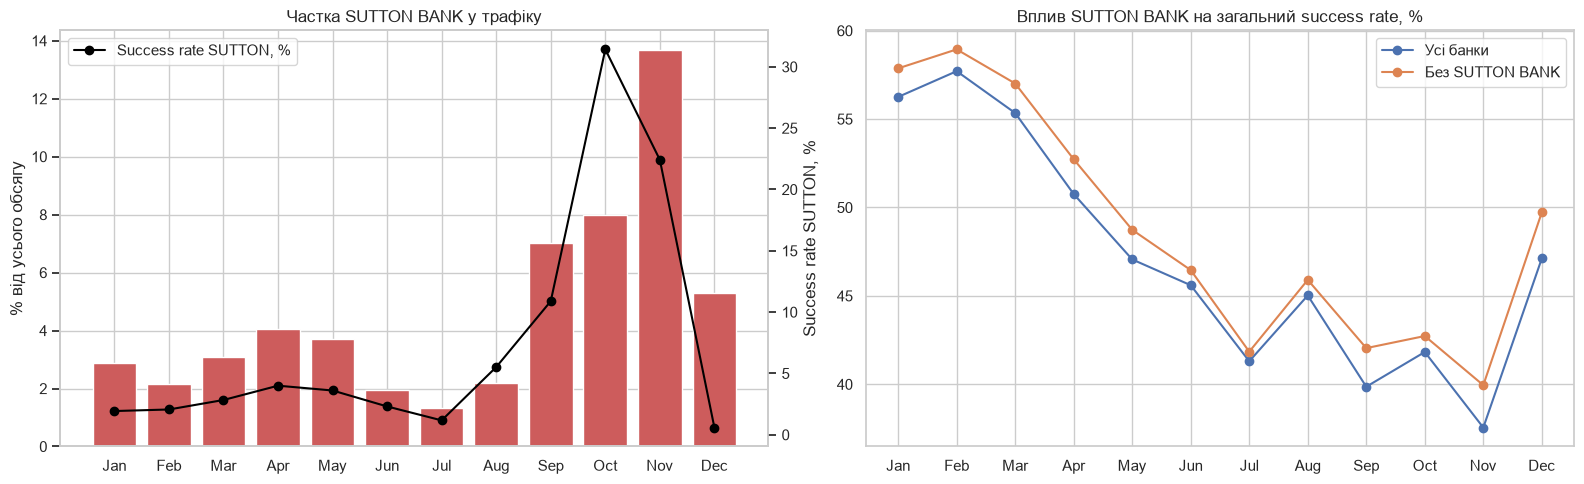

Success rate без SUTTON BANK: {1: 57.9, 2: 58.9, 3: 57.0, 4: 52.7, 5: 48.7, 6: 46.5, 7: 41.8, 8: 45.9, 9: 42.0, 10: 42.7, 11: 39.9, 12: 49.7}


In [19]:
sr_excl_sutton = df[df['bank_name'] != 'SUTTON BANK'].groupby('month')['is_success'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].bar(sutton_monthly.index, sutton_monthly['share_of_total_%'], color='indianred')
axes[0].set_ylabel('% від усього обсягу'); axes[0].set_title('Частка SUTTON BANK у трафіку')
ax2 = axes[0].twinx()
ax2.plot(sutton_monthly.index, sutton_monthly['success_rate'], color='black', marker='o', label='Success rate SUTTON, %')
ax2.set_ylabel('Success rate SUTTON, %'); ax2.grid(False); ax2.legend(loc='upper left')

axes[1].plot(monthly.index, monthly['success_rate'], marker='o', label='Усі банки')
axes[1].plot(sr_excl_sutton.index, sr_excl_sutton.values, marker='o', label='Без SUTTON BANK')
axes[1].set_title('Вплив SUTTON BANK на загальний success rate, %'); axes[1].legend()
for ax in (axes[0], axes[1]):
    ax.set_xticks(range(1, 13)); ax.set_xticklabels(MONTHS)
plt.tight_layout(); plt.show()
print("Success rate без SUTTON BANK:", sr_excl_sutton.round(1).to_dict())

**Виправлення до першої версії:** success rate SUTTON BANK — **не** «0.6–5.5% увесь рік». За таблицею: січень–серпень 1.2–5.5%, але **вересень 10.9%, жовтень 31.4%, листопад 22.4%**, у грудні 0.6%.
Тобто в піковий період з банком відбувається щось якісно інше (інший трафік? інша схема? зміна правил?), і саме на цей період припадає піковий обсяг (13.7% усього трафіку в листопаді). Колонка `tx_per_user` допоможе відрізнити «багато користувачів по 1–2 спроби» від «мало користувачів з великою кількістю спроб» (ознака card testing).

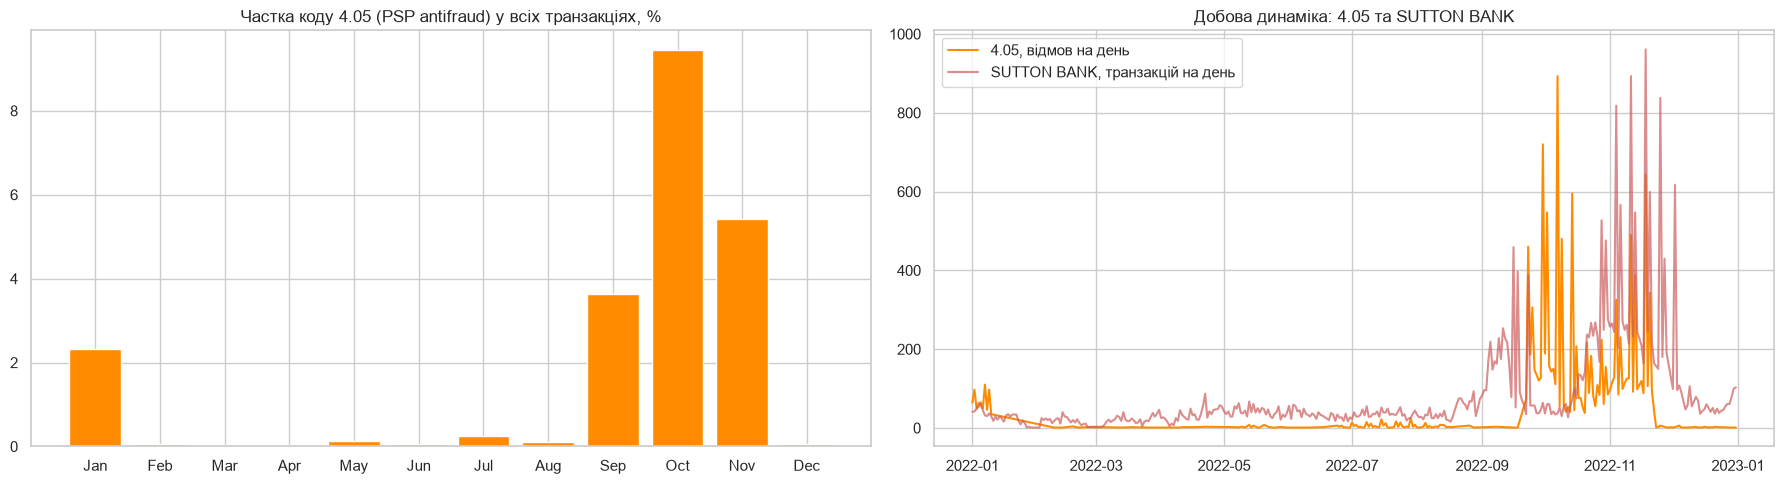

Частка 4.05 по місяцях, %: {1: 2.33, 2: 0.06, 3: 0.04, 4: 0.04, 5: 0.14, 6: 0.05, 7: 0.24, 8: 0.1, 9: 3.64, 10: 9.44, 11: 5.42, 12: 0.07}

Усього відмов 4.05: 12,772; у вер–лис: 11,705 (91.6%)
Пік добових 4.05: 2022-10-07 893

Banks серед 4.05 у вер–лис (топ-8), %:


,share_%
bank_name,
JPMORGAN CHASE BANK N.A.,12.00
BBVA BANCOMER S.A.,7.60
"CAPITAL ONE, NATIONAL ASSOCIATION",6.90
AMERICAN EXPRESS COMPANY,6.80
CITIBANK N.A.,3.80
"CAPITAL ONE BANK (USA), NATIONAL ASSOCIATION",3.70
GOLDMAN SACHS BANK USA,2.90
"STRIDE BANK, NATIONAL ASSOCIATION",2.40


Країни серед 4.05 у вер–лис (топ-5): {'USA': 7859, 'MEX': 2093, 'BRA': 726, 'ARG': 318, 'AUS': 128}
initial / recurrent серед 4.05 у вер–лис: {'reccurent': 10376, 'initial': 1329}


In [20]:
err405 = df[df['error_type'] == 4.05]

m405 = err405.groupby('month').size().reindex(range(1, 13), fill_value=0)
pct405 = m405 / monthly['tx_count'] * 100

daily405 = err405.groupby('date').size()
daily_sutton = sutton.groupby('date').size()

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
axes[0].bar(pct405.index, pct405.values, color='darkorange')
axes[0].set_xticks(range(1, 13)); axes[0].set_xticklabels(MONTHS)
axes[0].set_title('Частка коду 4.05 (PSP antifraud) у всіх транзакціях, %')
axes[1].plot(daily405.index, daily405.values, color='darkorange', label='4.05, відмов на день')
axes[1].plot(daily_sutton.index, daily_sutton.values, color='indianred', alpha=.7, label='SUTTON BANK, транзакцій на день')
axes[1].set_title('Добова динаміка: 4.05 та SUTTON BANK'); axes[1].legend()
plt.tight_layout(); plt.show()
print("Частка 4.05 по місяцях, %:", pct405.round(2).to_dict())

sep_nov = err405[err405['month'].isin([9, 10, 11])]
print(f"\nУсього відмов 4.05: {len(err405):,}; у вер–лис: {len(sep_nov):,} ({len(sep_nov)/len(err405)*100:.1f}%)")
print("Пік добових 4.05:", daily405.idxmax().date(), daily405.max())
print("\nBanks серед 4.05 у вер–лис (топ-8), %:")
display((sep_nov['bank_name'].value_counts(normalize=True).head(8) * 100).round(1).to_frame('share_%'))
print("Країни серед 4.05 у вер–лис (топ-5):", sep_nov['card_country'].value_counts().head(5).to_dict())
print("initial / recurrent серед 4.05 у вер–лис:", sep_nov['payment_number'].value_counts().to_dict())

**Виправлення до першої версії:** частка 4.05 по місяцях — січень **2.33%** (не «~0»), лютий–серпень 0.04–0.24%, вересень 3.64%, жовтень 9.44%, листопад 5.42%, грудень 0.07% (у першій версії текст містив 3.9 / 10.2 / 6.3 — це не збігалося з виводом).
Тобто «з нуля» не зовсім так: був короткий сплеск у січні, потім вікно вересень–листопад і повернення до норми в грудні. Правило схоже на таке, яке **вмикали й вимикали**.
Клітинка вище показує, яка частка цих відмов припадає на SUTTON BANK (якщо велика — це одна історія, а не дві).

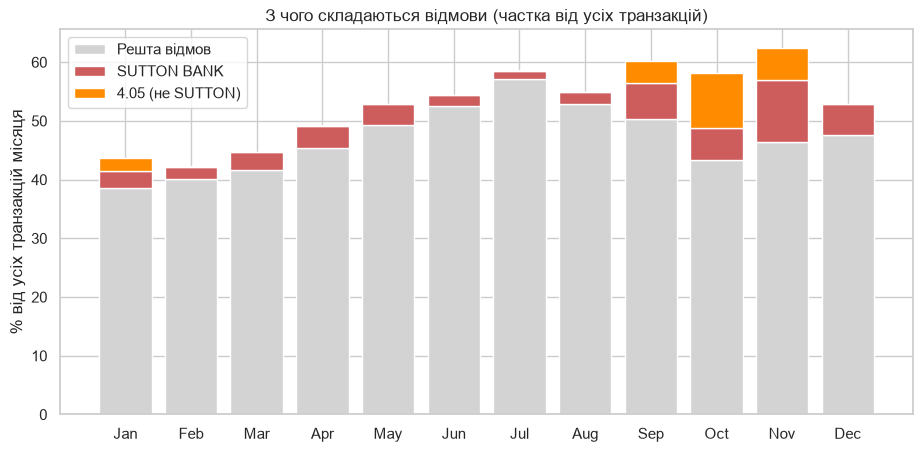

bucket,4.05 (не SUTTON),SUTTON BANK,Решта відмов
month,,,
1,2.30,2.80,38.60
2,0.10,2.10,40.10
3,0.00,3.00,41.60
4,0.00,3.90,45.30
5,0.10,3.60,49.20
6,0.10,1.90,52.50
7,0.20,1.30,57.10
8,0.10,2.10,52.80
9,3.60,6.20,50.30


Верхня межа потенційно втраченого доходу через відмови 4.05 (сума price цих спроб, у валюті платежу):
{'EUR': 8140.0, 'USD': 422820.0} — частину клієнтів було б повернено повторною спробою, тому це оцінка зверху


In [21]:
# Декомпозиція відмов по місяцях: SUTTON / 4.05 поза SUTTON / решта
f = df[df['is_success'] == 0].copy()
f['bucket'] = np.select(
    [f['bank_name'] == 'SUTTON BANK', f['error_type'] == 4.05],
    ['SUTTON BANK', '4.05 (не SUTTON)'], default='Решта відмов')
dec = f.groupby(['month', 'bucket']).size().unstack(fill_value=0).reindex(range(1, 13), fill_value=0)
dec_pct_of_tx = dec.div(monthly['tx_count'], axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 5))
bottom = np.zeros(12)
for col, color in zip(['Решта відмов', 'SUTTON BANK', '4.05 (не SUTTON)'], ['lightgray', 'indianred', 'darkorange']):
    if col in dec_pct_of_tx:
        ax.bar(dec_pct_of_tx.index, dec_pct_of_tx[col], bottom=bottom, label=col, color=color)
        bottom += dec_pct_of_tx[col].values
ax.set_xticks(range(1, 13)); ax.set_xticklabels(MONTHS)
ax.set_ylabel('% від усіх транзакцій місяця'); ax.set_title('З чого складаються відмови (частка від усіх транзакцій)')
ax.legend(); plt.show()
display(dec_pct_of_tx.round(1))

lost = err405.groupby('currency')['price'].sum()
print("Верхня межа потенційно втраченого доходу через відмови 4.05 (сума price цих спроб, у валюті платежу):")
print(lost.round(0).to_dict(), "— частину клієнтів було б повернено повторною спробою, тому це оцінка зверху")

# 9. Висновки та рекомендації

## Ключові інсайти (усі числа — з виводів вище)

|  | Інсайт | Підтвердження |
|--|---|---|
| 1 | Обсяг зріс ≈×2.9 (Jan 28.7K → Jul 83.4K), success rate впав з 56.3% до мінімуму 37.6% (Nov), але у грудні відновився до 47.1% | розділ 6 |
| 2 | Розбіжність: initial SR ↑ (35.4%→50.0%), recurrent SR ↓ (60.7%→33.0% у листопаді, 46.3% у грудні); recurrent ≈ 75% обсягу | розділ 7 |
| 3 | Головна причина відмов recurrent — 3.02 «Недостатньо коштів»: 22.3% (Jan) → 26–30% (Apr–Dec), пік 36.6% (Nov). Це *soft decline*, придатний для retry | розділ 7 |
| 4 | SUTTON BANK (USA, 96% PREPAID): 29.4K tx (5.2%), SR 15.2%. Січ–серп SR 1.2–5.5%, але вер 10.9% / жов 31.4% / лис 22.4%; частка трафіку піднялась до 13.7% у листопаді, в грудні SR 0.6% | розділ 8 |
| 5 | Код 4.05 (PSP antifraud): 91.6% усіх відмов 4.05 припадає на вер–лис (3.6% / 9.4% / 5.4% трафіку), у грудні 0.07%; 7 859 із них — картки США | розділ 8 |
| 6 | SUTTON і 4.05 збігаються в часі (вер–лис) — ймовірно, пов'язані; ступінь перетину дивись у виводі клітинки 8 (частка SUTTON серед 4.05) | розділ 8 |
| 7 | Ще два великі банки з низьким SR: THE BANCORP BANK 27.5%, STRIDE BANK 24.5% | розділ 8 |
| 8 | 8.5% транзакцій — у EUR; дохід і ціни аналізувати окремо по валютах | розділ 3.1 |
